# Breast Cancer Wisconsin (Diagnostic) — Full ML Pipeline
### the Goal is to Maximum possible accuracy + minimize the False Neagative for Maligant Calss

**why we do it?**
- due to the dangerous for the Maligant Class over than the other class


## Table of Contents
1. Libraries Setup
2. Load Data & Check for High Correlation
3. EDA (Exploratory Data Analysis)
4. Preprocessing
5. Encoding
6. Split Data & Scaling
7. Cross-Validation Setup
8. Handling Class Imbalance
9. Pipeline Builder
10. Baseline Models Definition
11. Baseline Models Comparison (CV)
12. Hyperparameter Tuning (Optuna)
13. Build Final Tuned Models
14. Stacking Ensemble
15. Optimal Decision Threshold Search
16. Final Evaluation on Test Set
17. Save Model Pipeline & Summary


## 1. Libraries Setup

In [1]:
import pandas as pd
import numpy as np
##import matplotlib
#matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib, json
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_val_predict

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,roc_auc_score, f1_score, fbeta_score, recall_score, precision_score,roc_curve, precision_recall_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
!pip install catboost
from catboost import CatBoostClassifier
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 13.8 MB/s eta 0:00:00


In [2]:
sns.set_style('whitegrid')
#plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
#np.random.seed(RANDOM_STATE)


## 2. Load Data & Check for High Correlation

In [7]:
df = pd.read_csv('breast-cancer.csv')
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.head()


Shape: (569, 32)
Missing values: 0
Duplicate rows: 0


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Note:** no missing data or duplicated data.

## 3. EDA (Exploratory Data Analysis)

diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    0.63
M    0.37
Name: proportion, dtype: float64


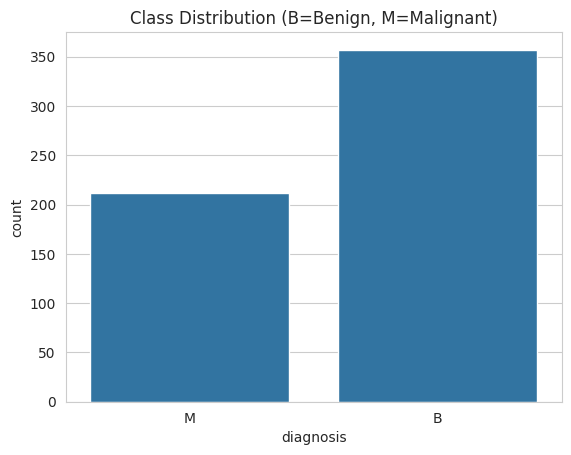

In [8]:
print(df['diagnosis'].value_counts())
print(df['diagnosis'].value_counts(normalize=True).round(2))

plt.figure()
sns.countplot(x='diagnosis', data=df)
plt.title('Class Distribution (B=Benign, M=Malignant)')
plt.savefig('01_class_balance.png')
plt.show()


**Columns overview:**

In [9]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

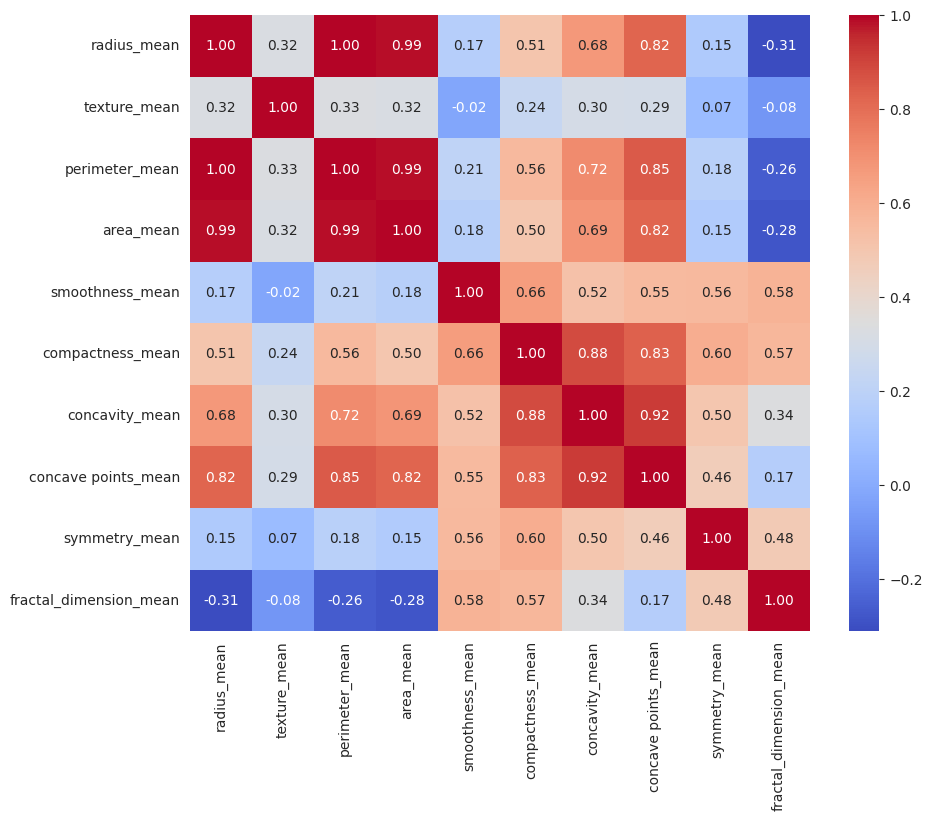

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.filter(regex='_mean$').corr(), annot=True,
            fmt='.2f', cmap='coolwarm')
plt.savefig('02_feature_correlations.png')
plt.show()

**Observation:** `radius_mean`, `perimeter_mean`, and `area_mean` are almost identical (highly correlated), so we can keep one and drop the others to avoid duplicated/redundant columns.

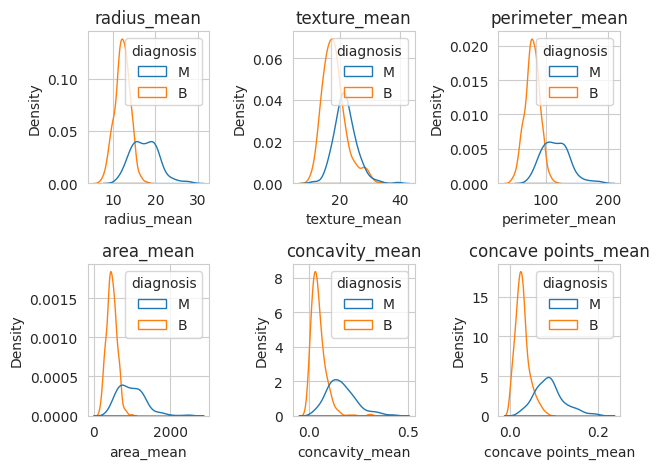

In [11]:
features = ['radius_mean','texture_mean','perimeter_mean','area_mean',
             'concavity_mean','concave points_mean']

fig, axes = plt.subplots(2,3)
for ax, feat in zip(axes.ravel(), features):
    sns.kdeplot(data=df, x=feat, hue='diagnosis', fill=True, alpha=0., ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.savefig('03_feature_distributions.png')
plt.show()


**Observation:** benign cases (B) have smaller radius and area values, whereas malignant cases (M) exhibit higher values with a wider spread.

## 4. Preprocessing

In [12]:
drop_cols = ['id', 'perimeter_mean', 'area_mean', 'perimeter_worst', 'area_worst', 'perimeter_se', 'area_se']
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])

**Check data types after loading:**

In [13]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

## 5. Encoding

In [14]:
df_clean.head()

,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,...,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,...,0.03003,0.006193,25.38,17.33,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,...,0.01389,0.003532,24.99,23.41,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,...,0.02250,0.004571,23.57,25.53,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,...,0.05963,0.009208,14.91,26.50,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,...,0.01756,0.005115,22.54,16.67,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Note:** we need to convert `diagnosis` from M/B to numbers, so we encode it with Label Encoding (it's the only object-type column).

In [15]:

le = LabelEncoder()
df_clean['diagnosis'] = le.fit_transform(df_clean['diagnosis'])  # sorted alphabetically: B=0, M=1
df_clean.head()


,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,...,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,...,0.03003,0.006193,25.38,17.33,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,...,0.01389,0.003532,24.99,23.41,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,...,0.02250,0.004571,23.57,25.53,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,...,0.05963,0.009208,14.91,26.50,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,...,0.01756,0.005115,22.54,16.67,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [32]:
import joblib
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

## 6. Split Data & Scaling

In [16]:
X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']
print("Cleaned Features Shape:", X.shape)
print("Class Distribution:\n", y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)


Cleaned Features Shape: (569, 24)
Class Distribution:
 diagnosis
0    0.627417
1    0.372583
Name: proportion, dtype: float64


## 7. Cross-Validation Setup

In [17]:
cross_v = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 8. Handling Class Imbalance (`scale_pos_weight` for XGBoost)

In [18]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

## 9. Pipeline Builder (Scaler + Classifier)

In [19]:
def build_pipeline(clf):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', clf)
    ])

## 10. Baseline Models Definition

In [20]:

from sklearn.pipeline import Pipeline

base_models = {
    "LogisticRegression": build_pipeline(LogisticRegression(max_iter=3000, class_weight='balanced')),
    "RandomForest": build_pipeline(RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced')),
    "GradientBoosting": build_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE)),
    "XGBoost": build_pipeline(XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0, scale_pos_weight=scale_pos_weight)),
    "LightGBM": build_pipeline(LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, class_weight='balanced')),
    "CatBoost": build_pipeline(CatBoostClassifier(verbose=0, random_state=RANDOM_STATE, auto_class_weights='Balanced')),
    "SVM": build_pipeline(SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE, class_weight='balanced')),
    "KNN": build_pipeline(KNeighborsClassifier(n_neighbors=5)),
}

## 11. Baseline Models — 5-Fold Cross-Validation Comparison

In [21]:
results = []
print("\n--- Cross Validation Baseline Comparison ---")
for name, pipe in base_models.items():
    acc = cross_val_score(pipe, X_train, y_train, cv=cross_v, scoring='accuracy')
    rec = cross_val_score(pipe, X_train, y_train, cv=cross_v, scoring='recall')
    auc = cross_val_score(pipe, X_train, y_train, cv=cross_v, scoring='roc_auc')
    results.append({
        "Model": name,
        "CV_Accuracy": acc.mean(),
        "CV_Recall_Malignant": rec.mean(),
        "CV_ROC_AUC": auc.mean(),
    })
    print(f"{name:20s} Acc={acc.mean():.4f} | Recall={rec.mean():.4f} | ROC-AUC={auc.mean():.4f}")

results_df = pd.DataFrame(results).sort_values('CV_ROC_AUC', ascending=False)


--- Cross Validation Baseline Comparison ---
LogisticRegression   Acc=0.9758 | Recall=0.9647 | ROC-AUC=0.9955
RandomForest         Acc=0.9670 | Recall=0.9353 | ROC-AUC=0.9919
GradientBoosting     Acc=0.9714 | Recall=0.9471 | ROC-AUC=0.9899
XGBoost              Acc=0.9714 | Recall=0.9529 | ROC-AUC=0.9932
LightGBM             Acc=0.9648 | Recall=0.9412 | ROC-AUC=0.9923
CatBoost             Acc=0.9714 | Recall=0.9529 | ROC-AUC=0.9930
SVM                  Acc=0.9758 | Recall=0.9647 | ROC-AUC=0.9948
KNN                  Acc=0.9626 | Recall=0.9059 | ROC-AUC=0.9848


## 12. Hyperparameter Tuning (Optuna)

In [22]:
def tune_xgb(trial):
    clf = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 500),
        max_depth=trial.suggest_int('max_depth', 2, 8),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        verbosity=0,
        scale_pos_weight=scale_pos_weight
    )
    pipe = build_pipeline(clf)
    return cross_val_score(pipe, X_train, y_train, cv=cross_v, scoring='roc_auc').mean()

In [23]:
def tune_lgbm(trial):
    clf = LGBMClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 500),
        max_depth=trial.suggest_int('max_depth', 2, 8),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        num_leaves=trial.suggest_int('num_leaves', 8, 64),
        random_state=RANDOM_STATE,
        verbose=-1,
        class_weight='balanced'
    )
    pipe = build_pipeline(clf)
    return cross_val_score(pipe, X_train, y_train, cv=cross_v, scoring='roc_auc').mean()

In [24]:
def tune_lr(trial):
    clf = LogisticRegression(
        C=trial.suggest_float('C', 0.001, 10, log=True),
        max_iter=3000,
        class_weight='balanced'
    )
    pipe = build_pipeline(clf)
    return cross_val_score(pipe, X_train, y_train, cv=cross_v, scoring='roc_auc').mean()

In [25]:
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(tune_xgb, n_trials=30)

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(tune_lgbm, n_trials=30)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(tune_lr, n_trials=30)
print(f"LogReg    best CV ROC-AUC: {study_lr.best_value:.4f} | {study_lr.best_params}")



LogReg    best CV ROC-AUC: 0.9955 | {'C': 0.9967856903430027}


## 13. Build Final Tuned Models

In [27]:
best_xgb_clf = XGBClassifier(**study_xgb.best_params, eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0, scale_pos_weight=scale_pos_weight)
best_lgbm_clf = LGBMClassifier(**study_lgbm.best_params, random_state=RANDOM_STATE, verbose=-1, class_weight='balanced')
best_lr_clf = LogisticRegression(**study_lr.best_params, max_iter=3000, class_weight='balanced')
best_rf_clf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced')

## 14. Stacking Ensemble

In [28]:
estimators = [
    ('xgb', best_xgb_clf),
    ('lgbm', best_lgbm_clf),
    ('rf', best_rf_clf),
    ('lr', best_lr_clf),
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=3000, class_weight='balanced'),
    cv=5
)
best_pipeline = build_pipeline(stacking_clf)
best_model_name = "StackingClassifier_Ensemble"


## 15. Optimal Decision Threshold Search (F2-Score, out-of-fold predictions)

In [29]:
print("\n--- Finding Optimal Decision Threshold via F2-Score ---")

# Get out-of-fold probability predictions without data leakage
y_cv_proba = cross_val_predict(best_pipeline, X_train, y_train, cv=cross_v, method='predict_proba')[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_cv_proba)

# Compute F2-score directly using Precision and Recall curves
f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-10)

# Select threshold that maximizes F2 score
best_threshold_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_threshold_idx]

print(f"Optimal Threshold (F2-Score Optimized): {best_threshold:.4f}")


--- Finding Optimal Decision Threshold via F2-Score ---
Optimal Threshold (F2-Score Optimized): 0.5261


## 16. Final Evaluation on Test Set


             EVALUATION ON TEST SET             
Test ROC-AUC: 0.9964

--- Default Threshold (0.50) ---
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

--- Optimized Threshold (0.53) ---
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



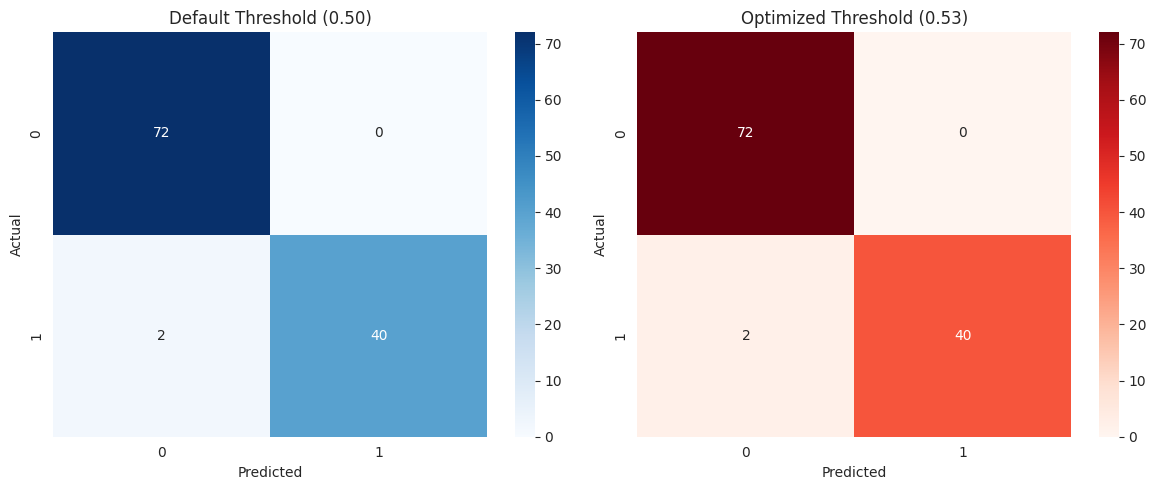

In [30]:
best_pipeline.fit(X_train, y_train)

y_test_proba = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_default = (y_test_proba >= 0.5).astype(int)
y_pred_opt = (y_test_proba >= best_threshold).astype(int)

print("\n" + "="*55)
print("             EVALUATION ON TEST SET             ")
print("="*55)
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}\n")

print("--- Default Threshold (0.50) ---")
print(classification_report(y_test, y_pred_default, target_names=['Benign', 'Malignant']))

print(f"--- Optimized Threshold ({best_threshold:.2f}) ---")
print(classification_report(y_test, y_pred_opt, target_names=['Benign', 'Malignant']))

# Plot Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_default), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Default Threshold (0.50)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title(f'Optimized Threshold ({best_threshold:.2f})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 17. Save Model Pipeline & Summary

In [31]:
joblib.dump(best_pipeline, 'best_breast_cancer_pipeline.pkl')

export_summary = {
    'model_name': best_model_name,
    'optimal_threshold': float(best_threshold),
    'test_roc_auc': float(roc_auc_score(y_test, y_test_proba)),
    'test_recall_malignant_optimized': float(recall_score(y_test, y_pred_opt)),
    'test_precision_malignant_optimized': float(precision_score(y_test, y_pred_opt))
}

with open('model_summary.json', 'w') as f:
    json.dump(export_summary, f, indent=2)

print("\nModel pipeline and metadata successfully saved!")


Model pipeline and metadata successfully saved!
